In [24]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix,f1_score
import joblib

In [25]:
df=pd.read_csv('../data/bank_customer_data.csv')

In [26]:
df['default'].value_counts(normalize=True)

default
0    0.80252
1    0.19748
Name: proportion, dtype: float64

<Axes: >

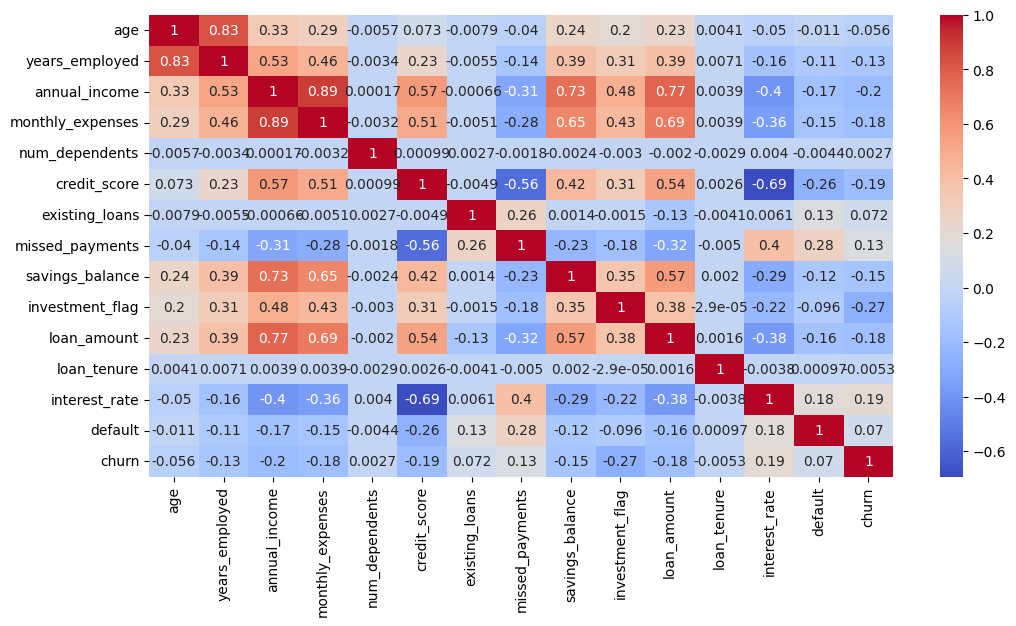

In [27]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True),annot=True,cmap='coolwarm')

In [28]:
df.columns

Index(['customer_id', 'age', 'gender', 'marital_status', 'education',
       'employment_type', 'years_employed', 'annual_income',
       'monthly_expenses', 'num_dependents', 'credit_score', 'existing_loans',
       'missed_payments', 'savings_balance', 'investment_flag', 'loan_amount',
       'loan_tenure', 'interest_rate', 'default', 'churn', 'credit_risk'],
      dtype='str')

In [29]:
df.drop(['customer_id','gender','marital_status','num_dependents','loan_tenure','credit_risk','loan_amount','churn'],axis=1,inplace=True)

In [30]:
df=pd.get_dummies(df,columns=['employment_type'],drop_first=True)

In [31]:
df['education']=df['education'].map({
    'Graduate':1,
    'High School':0,
    'Postgraduate':2
})

In [32]:
df.head()

,age,education,years_employed,annual_income,monthly_expenses,credit_score,existing_loans,missed_payments,savings_balance,investment_flag,interest_rate,default,employment_type_Self-Employed,employment_type_Unemployed
0,56,1,33,627221,27346,684,1,1,292746,1,18.45,0,False,False
1,69,1,40,668372,34942,613,2,0,137967,0,15.79,0,False,False
2,46,0,26,554249,26827,478,1,1,60548,0,22.06,1,True,False
3,32,1,7,593807,34816,663,5,1,289507,0,20.94,0,True,False
4,60,0,31,396889,13767,610,0,0,155872,1,19.68,0,False,False


In [33]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   age                            50000 non-null  int64  
 1   education                      50000 non-null  int64  
 2   years_employed                 50000 non-null  int64  
 3   annual_income                  50000 non-null  int64  
 4   monthly_expenses               50000 non-null  int64  
 5   credit_score                   50000 non-null  int64  
 6   existing_loans                 50000 non-null  int64  
 7   missed_payments                50000 non-null  int64  
 8   savings_balance                50000 non-null  int64  
 9   investment_flag                50000 non-null  int64  
 10  interest_rate                  50000 non-null  float64
 11  default                        50000 non-null  int64  
 12  employment_type_Self-Employed  50000 non-null  bool   
 1

In [37]:
X=df.drop(['default'],axis=1)
y=df['default']

In [38]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,random_state=42,stratify=y)

In [45]:
imb_ratio=df['default'].value_counts()[0]/df['default'].value_counts()[1]
print(imb_ratio)
models={
    'LogisticRegression':Pipeline([
        ('scaler',StandardScaler()),
        ('model',LogisticRegression(max_iter=1000,class_weight='balanced'))
    ]),
    'SVM':Pipeline([
        ('scaler',StandardScaler()),
        ('model',SVC(class_weight='balanced'))
    ]),
    'KNN':Pipeline([
        ('scaler',StandardScaler()),
        ('model',KNeighborsClassifier())
    ]),
    'Decision Tree': DecisionTreeClassifier(class_weight='balanced'),
    'Random Forest':RandomForestClassifier(class_weight='balanced'),
    'XGboost':XGBClassifier(eval_metric='logloss',scale_pos_weight=round(imb_ratio))
}

for name,model in models.items():
    model.fit(X_train,y_train)
    y_train_pred=model.predict(X_train)
    y_pred=model.predict(X_test)
    print(f" the training accuracy of the model {name} is {accuracy_score(y_train,y_train_pred)} and testing accuracy is {accuracy_score(y_test,y_pred)}")

4.063803929511849
 the training accuracy of the model LogisticRegression is 0.6928 and testing accuracy is 0.6937333333333333
 the training accuracy of the model SVM is 0.6954571428571429 and testing accuracy is 0.6885333333333333
 the training accuracy of the model KNN is 0.8374 and testing accuracy is 0.788
 the training accuracy of the model Decision Tree is 1.0 and testing accuracy is 0.7202666666666667
 the training accuracy of the model Random Forest is 0.9999714285714286 and testing accuracy is 0.8095333333333333
 the training accuracy of the model XGboost is 0.8210285714285714 and testing accuracy is 0.707


In [47]:
for name in ['Random Forest','XGboost','Decision Tree']:
    y_pred=models[name].predict(X_test)
    print(f"{name}\n")
    print(classification_report(y_test,y_pred))

Random Forest

              precision    recall  f1-score   support

           0       0.82      0.98      0.89     12038
           1       0.58      0.13      0.21      2962

    accuracy                           0.81     15000
   macro avg       0.70      0.55      0.55     15000
weighted avg       0.77      0.81      0.76     15000

XGboost

              precision    recall  f1-score   support

           0       0.87      0.75      0.80     12038
           1       0.34      0.53      0.42      2962

    accuracy                           0.71     15000
   macro avg       0.60      0.64      0.61     15000
weighted avg       0.76      0.71      0.73     15000

Decision Tree

              precision    recall  f1-score   support

           0       0.83      0.83      0.83     12038
           1       0.29      0.29      0.29      2962

    accuracy                           0.72     15000
   macro avg       0.56      0.56      0.56     15000
weighted avg       0.72      0.72  

In [ ]:
# rf-default -recall-0.13 f1-.21
# xg-default -recall-0.53f1-.42
#dt-default-recall-0.29,f1-0.29

In [49]:
for name in ['Random Forest', 'XGboost']:
    cv_scores = cross_val_score(models[name], X_train, y_train, cv=5, scoring='f1')
    print(f"{name} | CV F1: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(cv_scores)

Random Forest | CV F1: 0.1979 (+/- 0.0089)
[0.19098458 0.19373892 0.21195974 0.20461266 0.18827709]
XGboost | CV F1: 0.4105 (+/- 0.0066)
[0.40817572 0.40547476 0.41739638 0.40253749 0.41908107]


In [61]:
params_xgb={
    'max_depth':[3,5,7],
    'n_estimators':[5,8,10,50,100,200],
    'scale_pos_weight':[3,5,7]
}
Grid_model=GridSearchCV(estimator=XGBClassifier(eval_metric='logloss'),param_grid=params_xgb,n_jobs=-1,cv=5,scoring='f1')
Grid_model.fit(X_train,y_train)
print(Grid_model.best_params_)
print(Grid_model.best_score_)
y_pred=Grid_model.predict(X_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

{'max_depth': 3, 'n_estimators': 10, 'scale_pos_weight': 3}
0.4371646128767468
0.7516666666666667
              precision    recall  f1-score   support

           0       0.87      0.81      0.84     12038
           1       0.40      0.51      0.45      2962

    accuracy                           0.75     15000
   macro avg       0.63      0.66      0.64     15000
weighted avg       0.78      0.75      0.76     15000



In [57]:
joblib.dump(Grid_model.best_estimator_, '../models/default_model.pkl')
print("Default model saved.")

Default model saved.


In [60]:
feature_imp=pd.Series(Grid_model.best_estimator_.feature_importances_,
                      index=X.columns
                      ).sort_values(ascending=False)
feature_imp

credit_score                     0.323949
annual_income                    0.235638
missed_payments                  0.202320
existing_loans                   0.090622
employment_type_Unemployed       0.069222
monthly_expenses                 0.032113
savings_balance                  0.023318
employment_type_Self-Employed    0.007977
interest_rate                    0.007904
age                              0.006936
years_employed                   0.000000
education                        0.000000
investment_flag                  0.000000
dtype: float32

## Observations

**Best Model:** XGBoost (n_estimators=10, max_depth=3, scale_pos_weight=3)
- CV F1: 0.437 | Test F1 on defaulters: 0.45 | Recall: 0.51

**Key Features:**
- credit_score (0.32) — strongest signal, low score = high default risk
- annual_income (0.24) — lower income customers default more
- missed_payments (0.20) — payment history directly predicts default

**Limitations:**
- Dataset is synthetically generated — real-world performance may differ
- Class 1 recall of 0.51 means we still miss half of actual defaulters
- years_employed, education, investment_flag had zero importance — may be dropped in future iteration